# SegNet: A Deep Convolutional Encoder-Decoder Architecture for Image Segmentation

In [ ]:
import zipfile
import torch
import numpy as np
from train import get_dataset, train_model
from model import SegNet
from utils import compute_metrics, show_predictions, list_show_annotation_torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

print(torch.__version__)

Using device: cuda
2.6.0+cu124


## Prepare the Dataset: CamVid

In [3]:
# download the dataset (zipped file)
!wget https://storage.googleapis.com/learning-datasets/fcnn-dataset.zip  -O /tmp/fcnn-dataset.zip

--2025-03-31 17:59:43--  https://storage.googleapis.com/learning-datasets/fcnn-dataset.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.175.207, 74.125.24.207, 142.251.10.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.175.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 125577577 (120M) [application/zip]
Saving to: ‘/tmp/fcnn-dataset.zip’

/tmp/fcnn-dataset.z 100%[===================>] 119.76M  21.3MB/s    in 6.9s    

2025-03-31 17:59:50 (17.4 MB/s) - ‘/tmp/fcnn-dataset.zip’ saved [125577577/125577577]



In [4]:
# extract the downloaded dataset to a local directory: /tmp/fcnn
local_zip = "/tmp/fcnn-dataset.zip"
with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall("/tmp/fcnn")

In [5]:
# show directories downloaded
!ls /tmp/fcnn/dataset1/

annotations_prepped_test  annotations_prepped_train  images_prepped_test  images_prepped_train


In [6]:
class_names = [
    "sky",
    "building",
    "column/pole",
    "road",
    "side walk",
    "vegetation",
    "traffic light",
    "fence",
    "vehicle",
    "pedestrian",
    "byciclist",
    "void",
]

In [ ]:
def get_config():
    return {
        "batch_size": 64,
        "img_size" : 224,
        "num_epochs": 260,
        "lr": 6e-5,
        "model_folder": "/content/drive/MyDrive/SegNet",
        "model_basename": "segnet_model_",
        "preload": "249",
        "experiment_name": "/runs/segnet_model",
    }

### Visualization

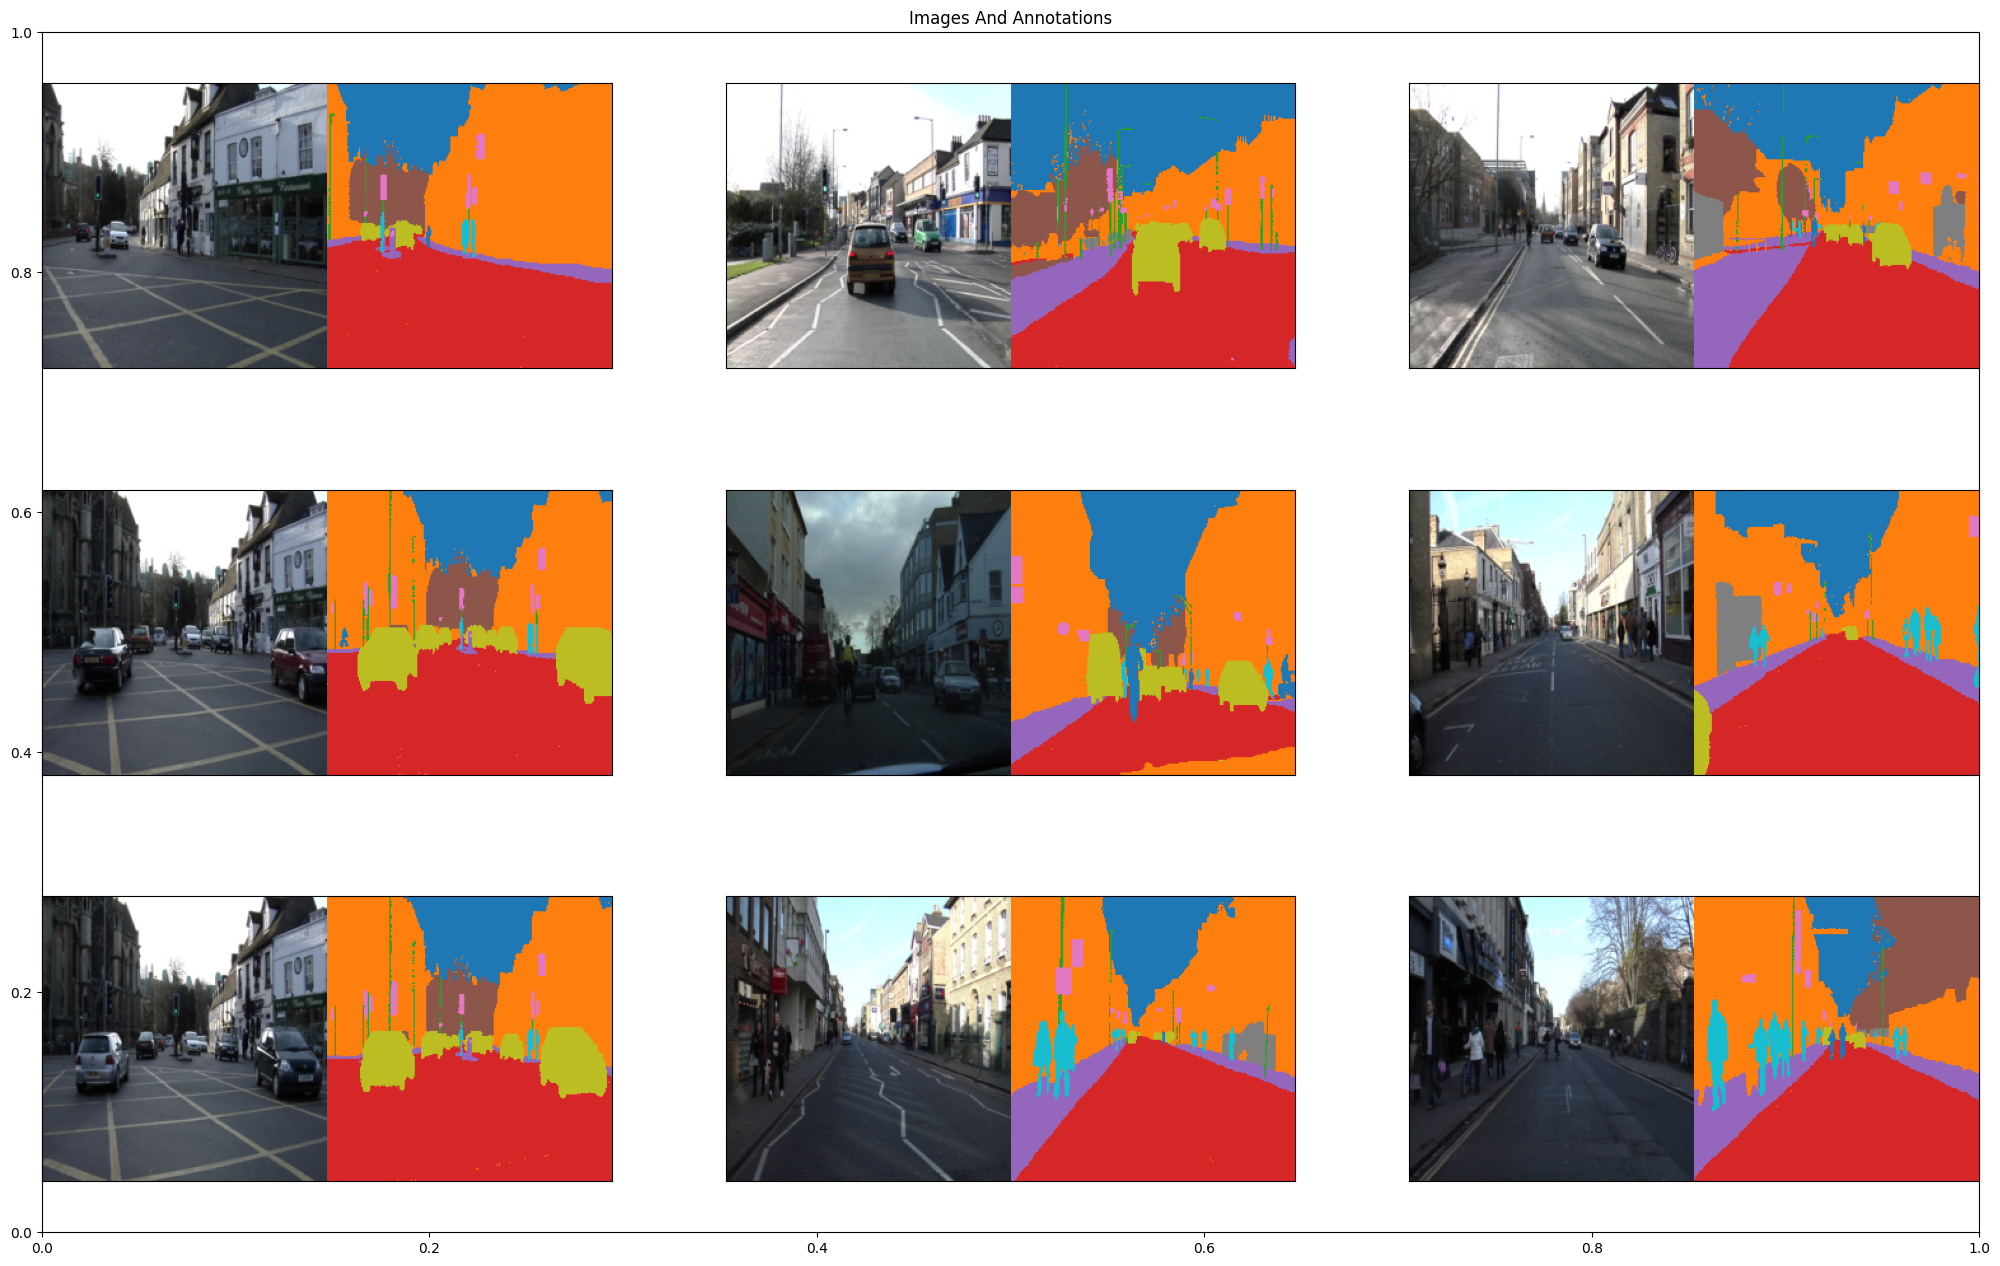

In [ ]:
config = get_config()
train_loader, _ = get_dataset(config)

list_show_annotation_torch(train_loader)

## Define the Model

In [ ]:
model = SegNet(num_classes=12)
model

SegNet(
  (encoder): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4):

## Train the Model

In [330]:
train_model(model, config)

Using device: cuda
Preloading model: /content/drive/MyDrive/SegNet/segnet_model_249.pt


Epoch [259/260]: 100%|██████████| 6/6 [00:13<00:00,  2.32s/it, accuracy=94.83, loss=0.236]


## Evaluate the Model

In [331]:
import itertools

y_true_images = []
y_true_segments = []
subset_size = 32

_, test_loader = get_dataset(config)

for image, annotation in itertools.islice(test_loader, subset_size // config["batch_size"] + 1):
    # remove batch dimension
    y_true_images.extend(image.cpu().numpy())
    y_true_segments.extend(annotation.cpu().numpy())

y_true_images = np.array(y_true_images)[:subset_size]
y_true_segments = np.array(y_true_segments)[:subset_size]

In [332]:
model.eval()
with torch.no_grad():
    all_predictions = []
    for batch_idx, (data, target) in enumerate(test_loader):
        data, target = data.to(device), target.to(device)
        output = model(data)
        # get class with max probability
        predictions = torch.argmax(output, dim=1)
        all_predictions.append(predictions.cpu().numpy())

results = np.concatenate(all_predictions, axis=0)

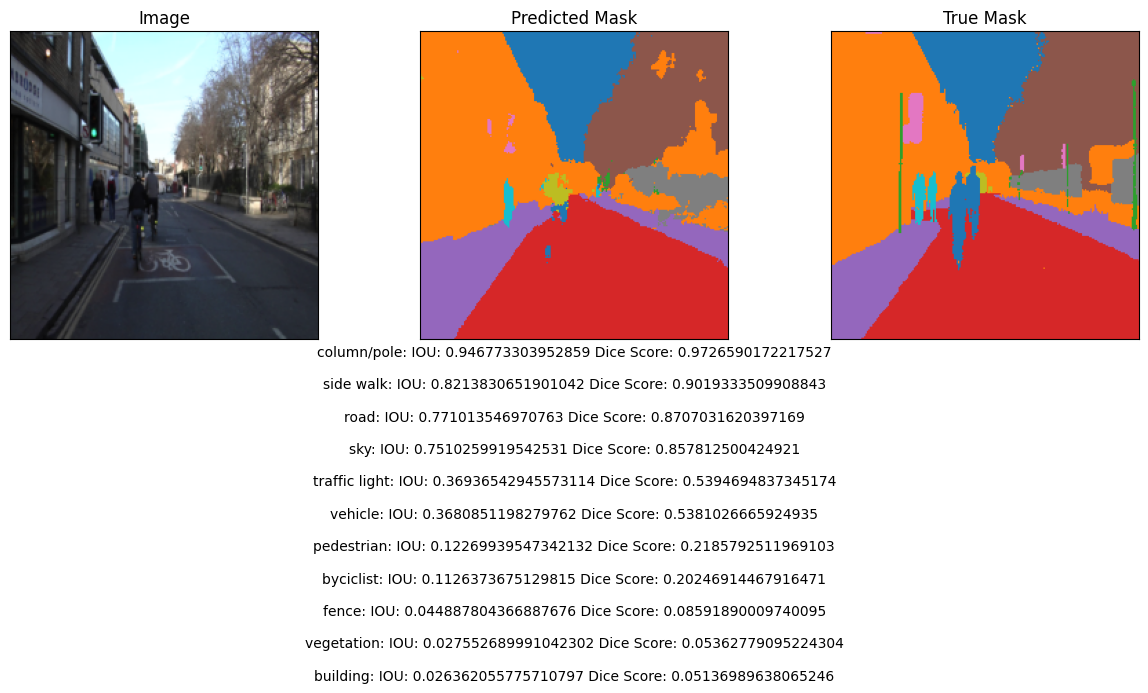

In [333]:
integer_slider = 0

iou, dice_score = compute_metrics(y_true_segments[integer_slider], results[integer_slider])

show_predictions(y_true_images[integer_slider], [results[integer_slider], y_true_segments[integer_slider]], ["Image", "Predicted Mask", "True Mask"], iou, dice_score, image_ordering="channels_first")

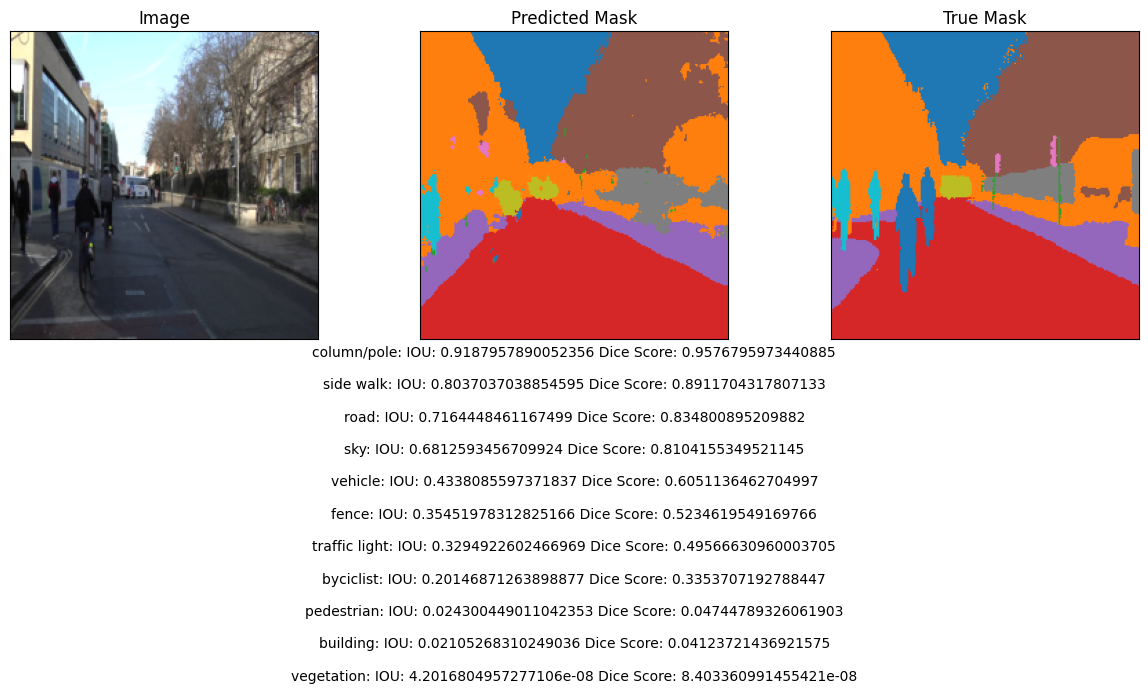

In [334]:
integer_slider = 14

iou, dice_score = compute_metrics(y_true_segments[integer_slider], results[integer_slider])

show_predictions(y_true_images[integer_slider], [results[integer_slider], y_true_segments[integer_slider]], ["Image", "Predicted Mask", "True Mask"], iou, dice_score, image_ordering="channels_first")

In [335]:
cls_wise_iou, cls_wise_dice_score = compute_metrics(y_true_segments, results[:subset_size])

In [336]:
for idx, iou in enumerate(cls_wise_iou):
    spaces = " " * (13-len(class_names[idx]) + 2)
    print(f"{class_names[idx]}{spaces}{iou}")

sky            0.7161169142289299
building       0.030728901892719068
column/pole    0.9355516054940063
road           0.7545059775420251
side walk      0.7745984697120494
vegetation     0.020383016367827172
traffic light  0.2323141610221232
fence          0.614537497988762
vehicle        0.06631925115309929
pedestrian     0.10700976549601235
byciclist      0.1532685445431657


In [337]:
# print the dice score for each class
for idx, dice_score in enumerate(cls_wise_dice_score):
  spaces = " " * (13-len(class_names[idx]) + 2)
  print(f"{class_names[idx]}{spaces}{dice_score}")

sky            0.8345782368320528
building       0.05962557537292435
column/pole    0.9667028281225046
road           0.8600779789013753
side walk      0.8729844896719445
vegetation     0.0399516966690391
traffic light  0.3770372335169562
fence          0.7612551567812031
vehicle        0.12438910977170752
pedestrian     0.19333120421816566
byciclist      0.26579853458920477
